# Interactive noise playground

Weeeee I love noisy play!

In [68]:
from matplotlib import pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import sys
sys.path.append("src/forest_gen")

In [70]:
width = 100
height = 100
resolution = 500

x = np.linspace(0, width, resolution)
y = np.linspace(0, height, resolution)
xx, yy = np.meshgrid(x, y)

vec_classify = np.vectorize(classify_terrain)
terrain = vec_classify(xx, yy)

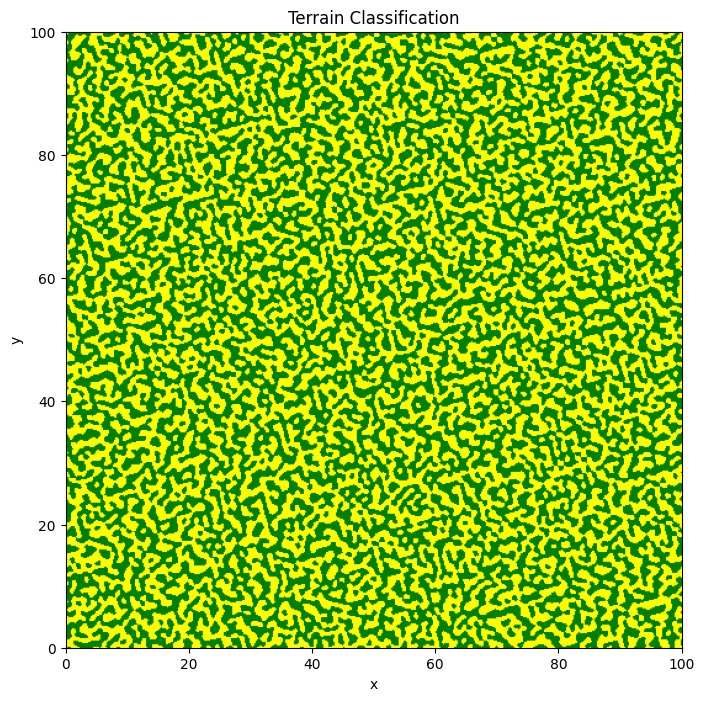

In [71]:
terrain_map = {"forest": 0, "plain": 1}
terrain_int = np.vectorize(terrain_map.get)(terrain)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["green", "yellow"])

plt.figure(figsize=(8, 8))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain Classification")
plt.show()

In [72]:
from asset_dist import grass_distribution

grass_final = grass_distribution(width, height)

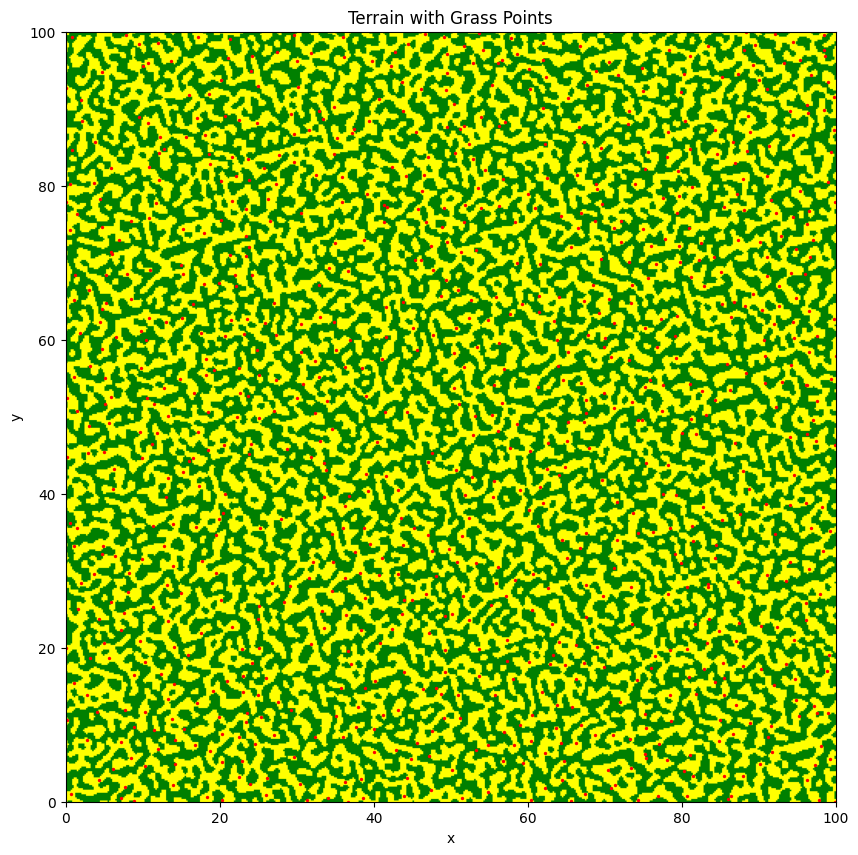

In [73]:
grass_x, grass_y = zip(*grass_final) if grass_final else ([], [])

plt.figure(figsize=(10, 10))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.scatter(grass_x, grass_y, s=2, c="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain with Grass Points")
plt.show()